新版本的figure2

In [17]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches
import sqlite3
from matplotlib.patches import ConnectionPatch, Rectangle

df_moves = pd.read_parquet(r'..\df_moves6.parquet')

elo_order = ['>=3000',  '2800-3000', '2600-2800', '2400-2600', '2200-2400',  '2000-2200', '<2000']
distinct_palette = sns.color_palette("viridis", len(elo_order))
color_map = dict(zip(elo_order, distinct_palette))

In [18]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed'],
      dtype='object')

### thinking time by elo

C:\Users\Administrator\AppData\Local\Temp\ipykernel_27008\1007352713.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_mean = df_moves.groupby('Progress_Bin')['Move_Time'].mean().reset_index()


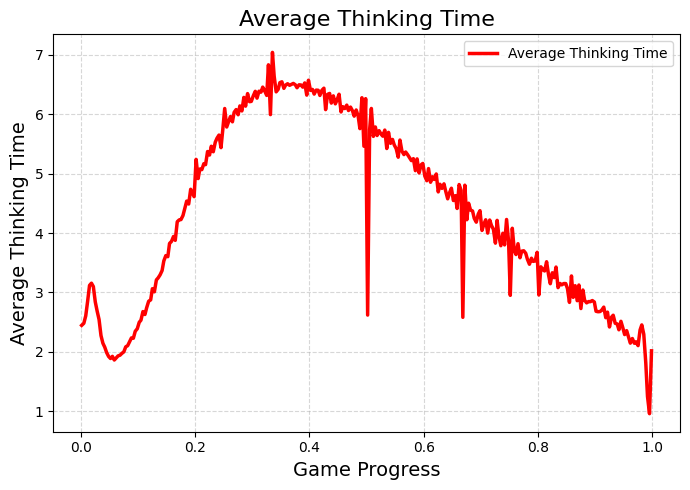

5318

In [19]:
plt.figure(figsize=(7, 5))
df_moves['Progress_Bin'] = pd.cut(df_moves['Progress'], bins=300)
df_mean = df_moves.groupby('Progress_Bin')['Move_Time'].mean().reset_index()
df_mean['Progress'] = df_mean['Progress_Bin'].apply(lambda x: x.mid).astype(float)

# 画均值线
plt.plot(df_mean['Progress'], df_mean['Move_Time'], color='red', linewidth=2.5, label=r'Average Thinking Time')
plt.title(r'Average Thinking Time', fontsize=16)
plt.xlabel('Game Progress', fontsize=14)
plt.ylabel(r'Average Thinking Time', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

del df_mean
gc.collect()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_27008\28772082.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df['Progress_Bin'] = (plot_df['Progress'] * 100).astype(int)


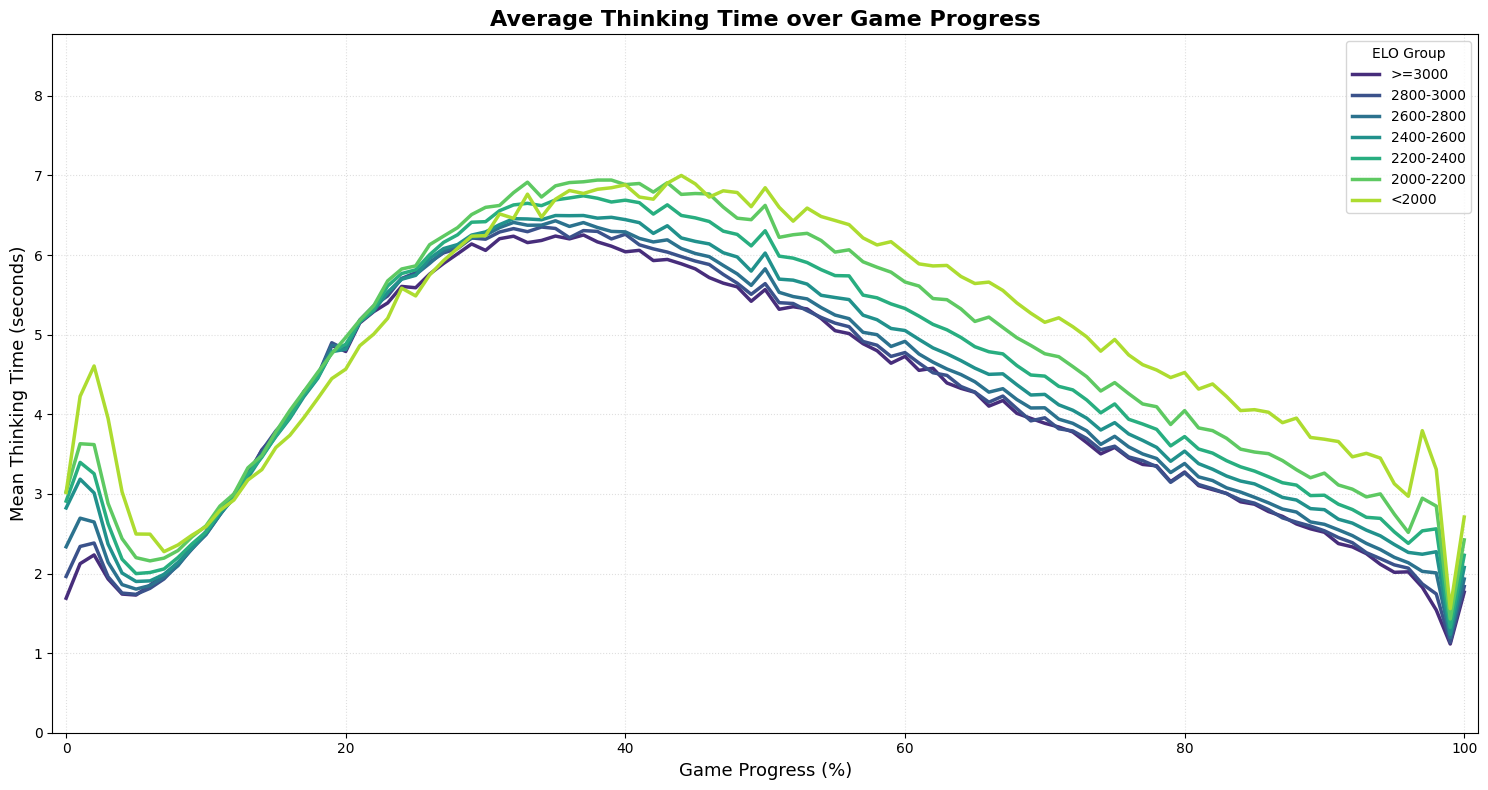

In [20]:
elo_order = ['>=3000',  '2800-3000', '2600-2800', '2400-2600', '2200-2400',  '2000-2200', '<2000']
distinct_palette = sns.color_palette("viridis", len(elo_order))

mask = df_moves['Is_Forced'] != 1
plot_df = df_moves[mask]

# 对 Progress 进行分箱
plot_df['Progress_Bin'] = (plot_df['Progress'] * 100).astype(int)

# 按 ELO 分组和进度分箱，平均 Move_Time
agg_trends = plot_df.groupby(['ELO_Group', 'Progress_Bin'])['Move_Time'].agg(
    mean_time='mean'  #均值受极端值影响太大，改成中位数了
).reset_index()

distinct_palette = sns.color_palette("viridis", len(elo_order))
color_map = dict(zip(elo_order, distinct_palette))
fig, ax = plt.subplots(figsize=(15, 8))
for group in elo_order:
    g_data = agg_trends[agg_trends['ELO_Group'] == group]
    # 排序确保线条从开局到残局连续
    g_data = g_data.sort_values('Progress_Bin')  
    ax.plot(g_data['Progress_Bin'], g_data['mean_time'], 
            color=color_map[group], linewidth=2.5, label=group)

ax.set_title('Average Thinking Time over Game Progress', fontsize=16, fontweight='bold')
ax.set_xlabel('Game Progress (%)', fontsize=13)
ax.set_xlim(-1, 101)
ax.set_ylabel('Mean Thinking Time (seconds)', fontsize=13)
# 限制 Y 轴范围：为了看清主体趋势，避免设太高会压扁曲线
ax.set_ylim(0, plot_df['Move_Time'].mean() * 2) 

ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(title='ELO Group', loc='upper right')

plt.tight_layout()
plt.show()

In [21]:
del plot_df
gc.collect()

4462

### Cognitive Speed and Game Progress

过滤前行数: 49125230
过滤后行数: 49125230


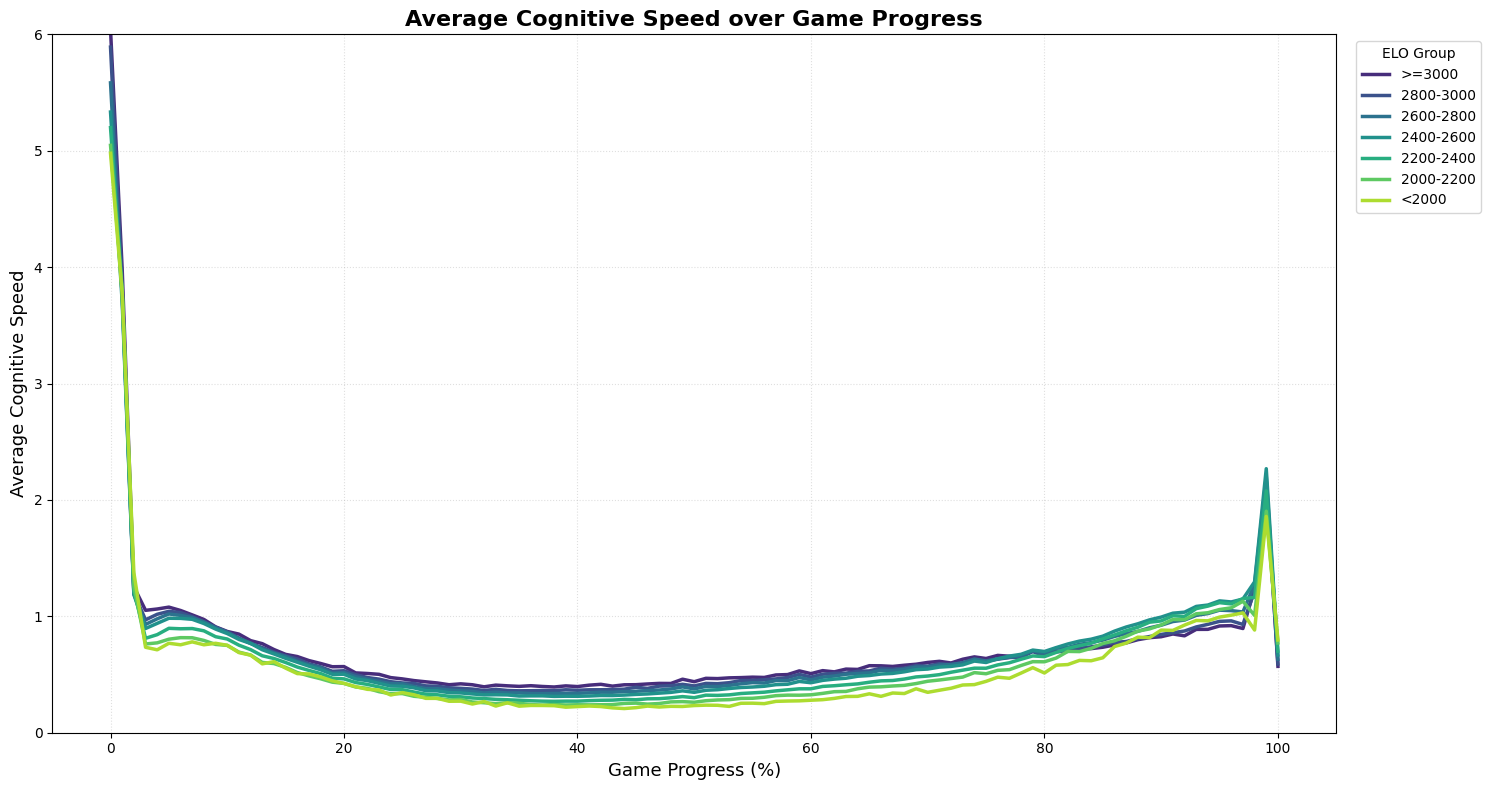

In [22]:
color_map = dict(zip(elo_order, distinct_palette))

mask = (df_moves['Is_Optimal'] == 1) & np.isfinite(df_moves['Cog_Speed']) # &(df_moves['Is_check'] == 0) & (df_moves['Is_checkmate'] == 0) &(df_moves['Is_Forced']==0)
time_complex = df_moves[mask].copy()
print(f"过滤前行数: {len(df_moves[(df_moves['Is_Optimal'] == 1) & np.isfinite(df_moves['Cog_Speed'])])}")
print(f"过滤后行数: {len(time_complex)}")

# 分箱
time_complex['Progress_Bin'] = (time_complex['Progress'] * 100).astype(int)

agg_metrics = time_complex.groupby(['ELO_Group', 'Progress_Bin'])['Cog_Speed'].agg(
    mean='mean'
).reset_index()

fig, ax = plt.subplots(figsize=(15, 8))
for group in elo_order:
    g_data = agg_metrics[agg_metrics['ELO_Group'] == group]
    ax.plot(g_data['Progress_Bin'], g_data['mean'], 
             color=color_map[group], linewidth=2.5, label=group)

ax.set_title(r'Average Cognitive Speed over Game Progress', fontsize=16, fontweight='bold')
ax.set_xlabel('Game Progress (%)', fontsize=13)  # 【新增】：把原本在下面那张图的 X 轴标签补上来
ax.set_ylabel('Average Cognitive Speed', fontsize=13)
# 均值天花板设为 10
ax.set_ylim(0, 6)  
ax.grid(True, linestyle=':', alpha=0.4)

ax.legend(title='ELO Group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

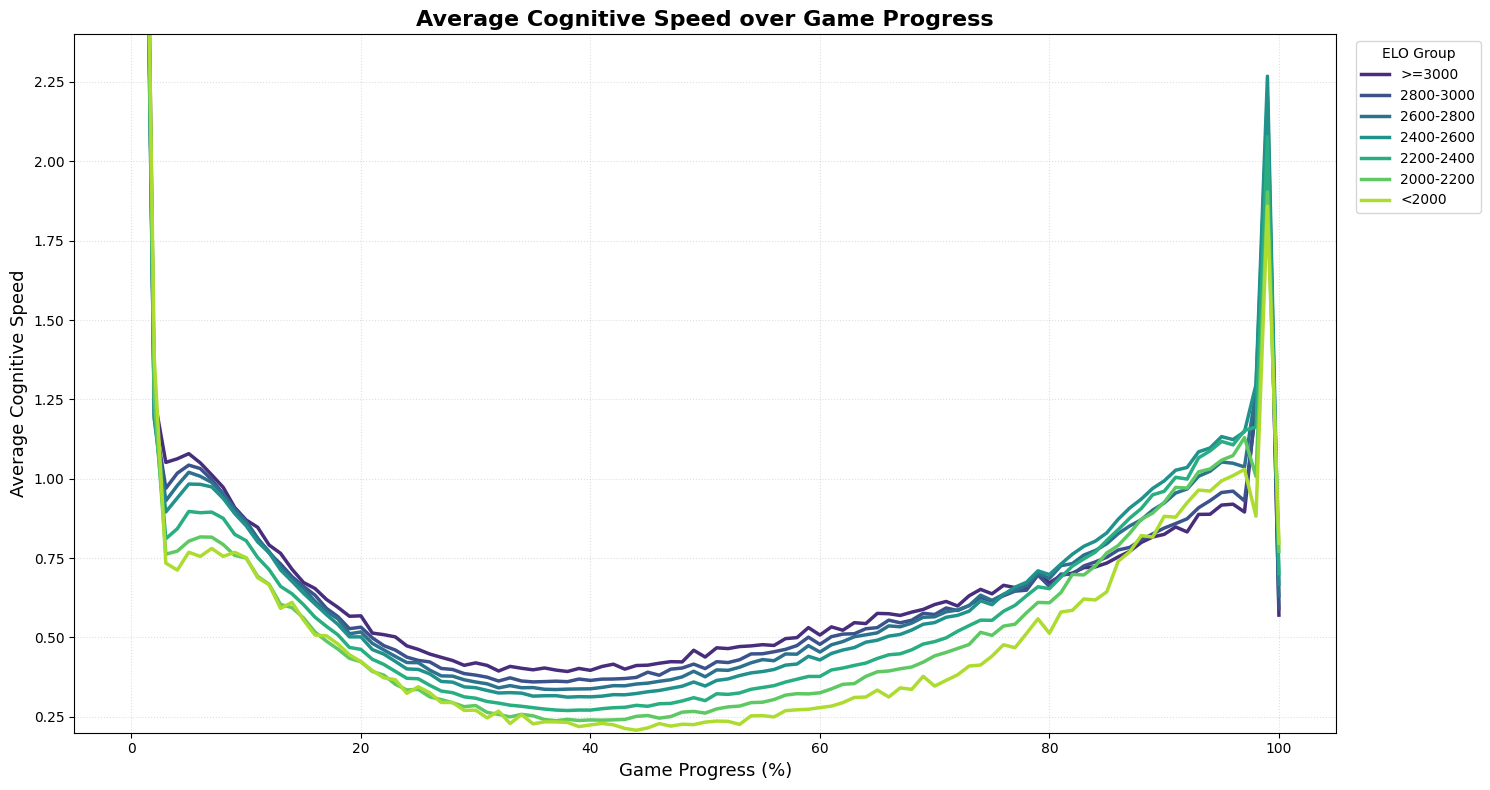

In [23]:
fig, ax = plt.subplots(figsize=(15, 8))
for group in elo_order:
    g_data = agg_metrics[agg_metrics['ELO_Group'] == group].sort_values('Progress_Bin')
    # 平滑，但也会丢失数据真实性
    # smooth = g_data['mean'].rolling(window=3, center=True).mean()
    ax.plot(g_data['Progress_Bin'], g_data['mean'], 
             color=color_map[group], linewidth=2.5, label=group)
ax.set_title(r'Average Cognitive Speed over Game Progress', fontsize=16, fontweight='bold')
ax.set_xlabel('Game Progress (%)', fontsize=13)  # 【新增】：把原本在下面那张图的 X 轴标签补上来
ax.set_ylabel('Average Cognitive Speed', fontsize=13)
# 均值天花板设为 10
ax.set_ylim(0.2, 2.4)  
ax.grid(True, linestyle=':', alpha=0.4)

ax.legend(title='ELO Group', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_27008\2398682102.py:74: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(wspace=0.1) # 手动调节两图之间的间距


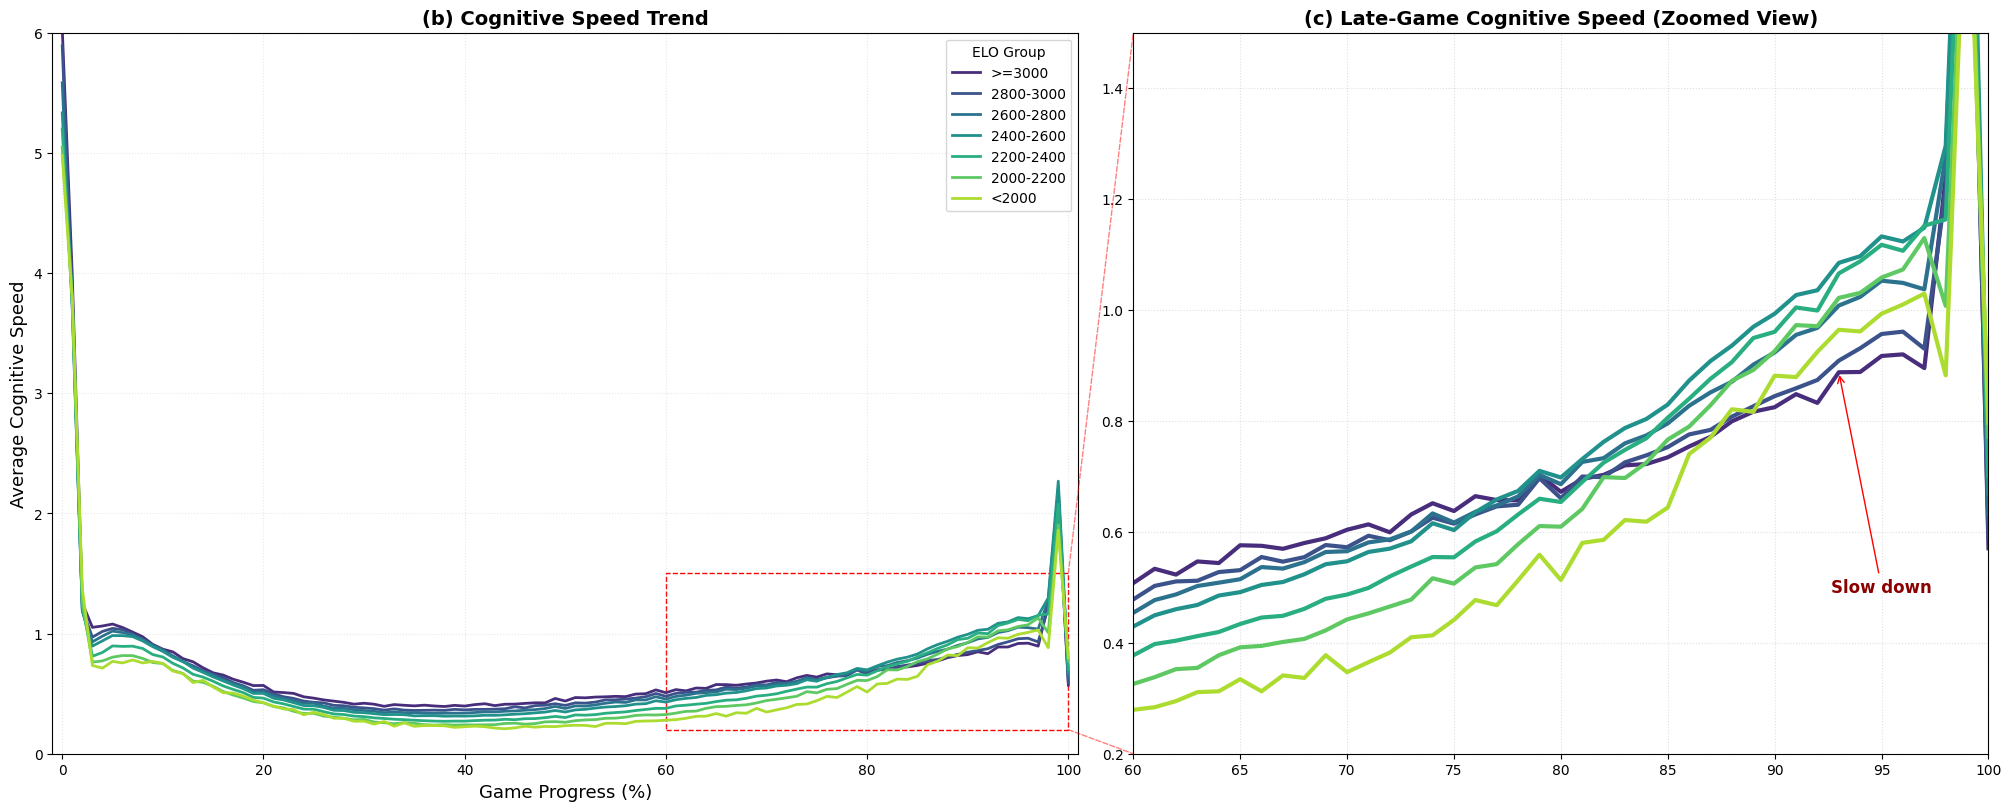

In [24]:
# 【手动调节区】 - 修改这里的数字即可
# ==========================================
# 1. 设置主图 (b) 中想要放大的矩形范围
zoom_x = (60, 100)    # X轴：进度从 80% 到 100%
zoom_y = (0.2, 1.5)   # Y轴：速度从 0.2 到 2.5

# 2. 设置 "Slow down" 标注的精准位置
target_line_group = '>=3000' # 你想指着哪条线？
arrow_tip_x = 93             # 箭尖指向的横坐标 (进度 %)
arrow_text_x = 95            # 文字所在的横坐标
arrow_text_y = 0.5           # 文字所在的纵坐标

# 绘图逻辑
fig, (ax_b, ax_c) = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw = {'width_ratios': [1.2, 1]}, constrained_layout=True) # 删掉可能导致冲突的布局参数

# 左侧主图 (b) 
for group in elo_order:
    g_data = agg_metrics[agg_metrics['ELO_Group'] == group].sort_values('Progress_Bin')
    ax_b.plot(g_data['Progress_Bin'], g_data['mean'], 
              color=color_map[group], linewidth=2, label=group)

ax_b.set_title('(b) Cognitive Speed Trend', fontsize=14, fontweight='bold')
ax_b.set_xlabel('Game Progress (%)', fontsize=13)
ax_b.set_ylabel('Average Cognitive Speed', fontsize=13)
ax_b.set_xlim(-1, 101)
ax_b.set_ylim(0, 6)
ax_b.grid(True, linestyle=':', alpha=0.3)

# 矩形框
rect = Rectangle((zoom_x[0], zoom_y[0]), zoom_x[1]-zoom_x[0], zoom_y[1]-zoom_y[0], 
                 linewidth=1, edgecolor='red', facecolor='none', linestyle='--')
ax_b.add_patch(rect)

# 右侧细节图 (c)
for group in elo_order:
    g_data = agg_metrics[agg_metrics['ELO_Group'] == group].sort_values('Progress_Bin')
    line, = ax_c.plot(g_data['Progress_Bin'], g_data['mean'], 
                     color=color_map[group], linewidth=3, label=group)  
    # 自动获取你想指的那条线在指定 X 位置的 Y 值
    if group == target_line_group:
        # 找到最接近 arrow_tip_x 的数据点
        idx = (g_data['Progress_Bin'] - arrow_tip_x).abs().idxmin()
        actual_y = g_data.loc[idx, 'mean']
# 配置 ax_c
ax_c.set_title('(c) Late-Game Cognitive Speed (Zoomed View)', fontsize=14, fontweight='bold')
ax_c.set_xlim(zoom_x)
ax_c.set_ylim(zoom_y)
ax_c.grid(True, linestyle=':', alpha=0.4)
# 标注 "Slow down"
# xy 是箭尖（数据坐标），xytext 是文字位置（数据坐标）
ax_c.annotate('Slow down', 
             xy=(arrow_tip_x, actual_y), # 箭尖精准指向该线的数值
             xytext=(arrow_text_x, arrow_text_y), # 文字位置
             arrowprops=dict(facecolor='red', edgecolor = 'red', arrowstyle='->', connectionstyle="arc3"),
             fontsize=12, color='darkred', rotation=0, 
             va='center', ha='center', fontweight='bold')

# 绘制连接线
# xyA 是主图的点（使用 data 坐标），xyB 是子图的点（使用 axes fraction 坐标）
# axes fraction: (0,0)是左下角，(0,1)是左上角
# 连线1：框的右上角 -> 子图的左上角
con1 = ConnectionPatch(xyA=(zoom_x[1], zoom_y[1]), coordsA="data",
                       xyB=(0, 1), coordsB="axes fraction",
                       axesA=ax_b, axesB=ax_c, color="red", linestyle="--", alpha=0.5)
fig.add_artist(con1)
# 连线2：框的右下角 -> 子图的左下角
con2 = ConnectionPatch(xyA=(zoom_x[1], zoom_y[0]), coordsA="data",
                       xyB=(0, 0), coordsB="axes fraction",
                       axesA=ax_b, axesB=ax_c, color="red", linestyle="--", alpha=0.5)
fig.add_artist(con2)

# 图例
ax_b.legend(title='ELO Group', loc='upper right')
plt.subplots_adjust(wspace=0.1) # 手动调节两图之间的间距
plt.show()

plt.close(fig) 
if 'agg_metrics' in locals(): del agg_metrics
if 'agg_delta' in locals(): del agg_delta
if 'df_delta' in locals(): del df_delta
if 'df_mini' in locals(): del df_mini

del fig, ax_b, ax_c, rect, con1, con2
gc.collect()

### Move Time over Remaining Time    
顶级棋手时间管理更好

In [25]:
df_moves.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed',
       'Progress_Bin'],
      dtype='object')

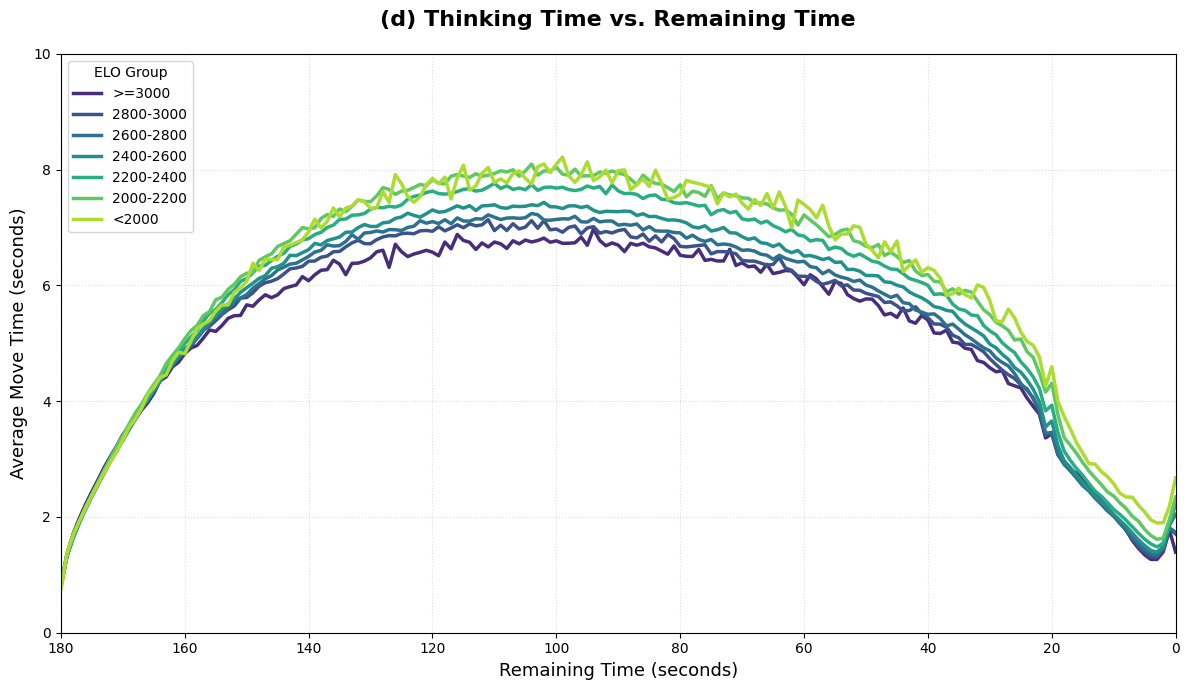

15058

In [40]:
mask_d = np.isfinite(df_moves['Remain_Time']) & np.isfinite(df_moves['Move_Time'])
df_mini = df_moves[['ELO_Group', 'Remain_Time', 'Move_Time']]
df_d = df_mini[mask_d]

# 设定分箱步长（比如每 15 秒一个区间，你可以根据总时长调整，比如 30 或 60）
bin_step = 1
df_d['Remain_Bin'] = (df_d['Remain_Time'] // bin_step) * bin_step

# 按照 ELO 和 剩余时间区间 分组计算平均用时
agg_d = df_d.groupby(['ELO_Group', 'Remain_Bin'])['Move_Time'].mean().reset_index()

# 3. 开始绘图
fig, ax = plt.subplots(figsize=(12, 7))

for group in elo_order:
    g_data = agg_d[agg_d['ELO_Group'] == group].sort_values('Remain_Bin', ascending=False)
    ax.plot(g_data['Remain_Bin'], g_data['Move_Time'], 
            color=color_map[group], linewidth=2.5, label=group)

# 4. 美化设置
ax.set_title('(d) Thinking Time vs. Remaining Time', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Remaining Time (seconds)', fontsize=13)
ax.set_ylabel('Average Move Time (seconds)', fontsize=13)

# 【关键点】：反转 X 轴
# 这样图的左边代表“刚开局/时间充裕”，右边代表“读秒/时间紧迫”
ax.set_xlim(180, 0) 

ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(title='ELO Group', loc='upper left')

# 限制 Y 轴防止长尾数据把图压扁
ax.set_ylim(0, 10) 

plt.tight_layout()
plt.show()

del mask_d
del df_d
del df_mini

gc.collect()

## top pleyers can make board easier

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:24: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27008\2710124017.py:22: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title('Verification: Mean $\Delta_{top5}$ (Position Clarity) over Progress', fontsize=16, fontweight='bold')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27008\2710124017.py:24: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('Mean $\Delta_{top5}$ (Objective Clarity)', fontsize=13)


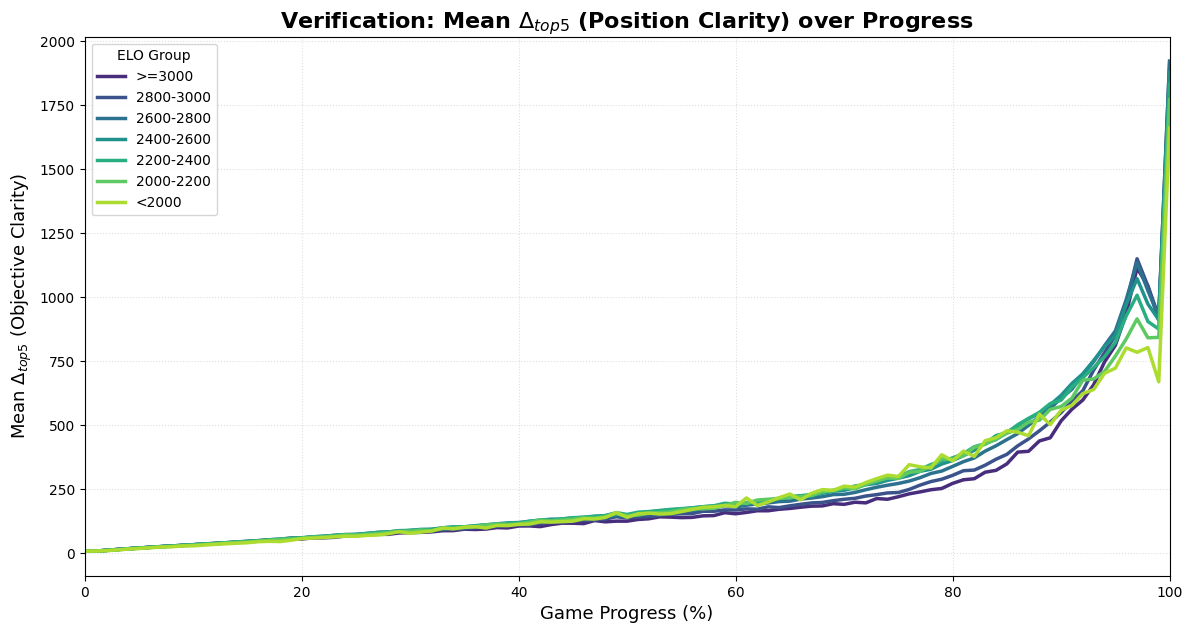

In [32]:
# 1. 提取必要数据并采样
# 假设你的列名就是 'Delta_top5'（或者是你自己计算出来的那个加权值）
# 确保包含 'ELO_Group', 'Progress', 'Delta_top5'
cols = ['ELO_Group', 'Progress', 'Δ'] 
df_delta = df_moves[cols].dropna() # 采样200万行足够了

# 2. 分箱处理 (1% 为一个箱子)
df_delta['Progress_Bin'] = (df_delta['Progress'] * 100).astype(int)

# 3. 按组计算均值
agg_delta = df_delta.groupby(['ELO_Group', 'Progress_Bin'])['Δ'].mean().reset_index()

# 4. 绘图
fig, ax = plt.subplots(figsize=(14, 7))

for group in elo_order:
    g_data = agg_delta[agg_delta['ELO_Group'] == group].sort_values('Progress_Bin')
    ax.plot(g_data['Progress_Bin'], g_data['Δ'], 
            color=color_map[group], linewidth=2.5, label=group)

# 5. 美化
ax.set_title('Verification: Mean $\Delta_{top5}$ (Position Clarity) over Progress', fontsize=16, fontweight='bold')
ax.set_xlabel('Game Progress (%)', fontsize=13)
ax.set_ylabel('Mean $\Delta_{top5}$ (Objective Clarity)', fontsize=13)
ax.set_xlim(0, 100)
ax.grid(True, linestyle=':', alpha=0.4)
ax.legend(title='ELO Group', loc = 'upper left')
plt.show()

# del df_delta
# gc.collect()

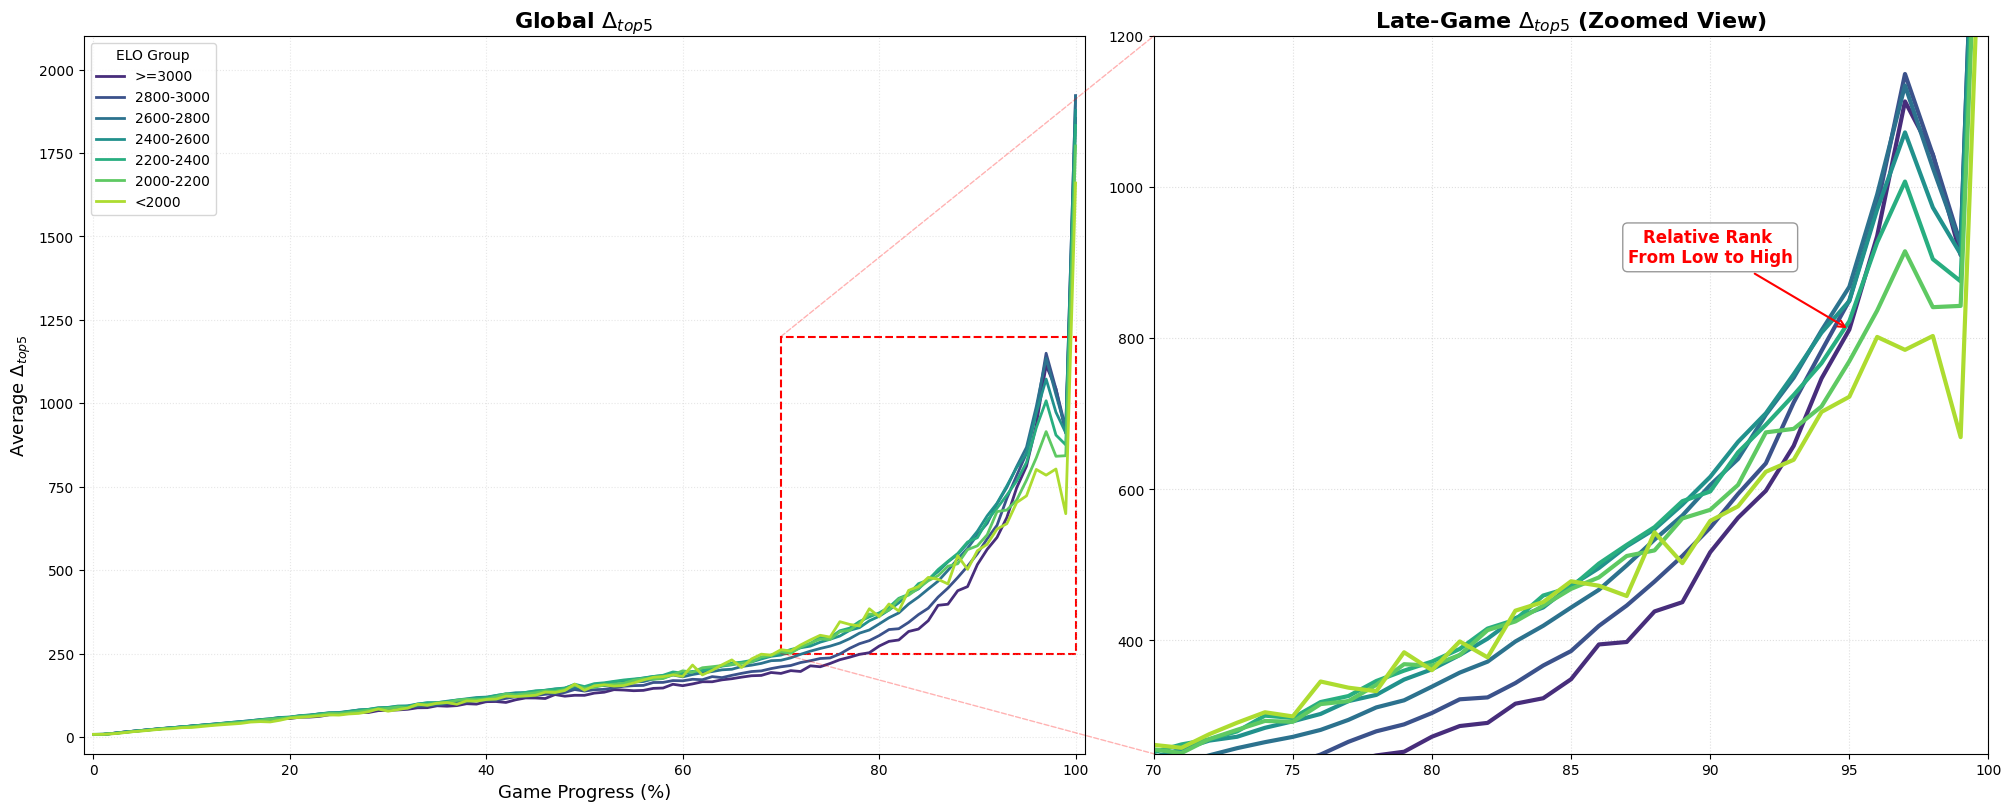

In [39]:
# 【手动调节区】
zoom_x_delta = (70, 100)    
zoom_y_delta = (250, 1200)  

# 标注：指向紫色线反超其他所有线的“超越点”或最终高点
target_group = '>=3000'
arrow_x = 95                # 指向末端最高点
arrow_text_x = 90           # 文字位置稍微往左靠，突出反超感
arrow_text_y = 900         # 文字高度

# 绘图逻辑
fig, (ax_main, ax_zoom) = plt.subplots(1, 2, figsize=(20, 8), 
                                       gridspec_kw={'width_ratios': [1.2, 1]}, 
                                       constrained_layout=True)

# --- 绘制左侧主图 (b) ---
for group in elo_order:
    g_data = agg_delta[agg_delta['ELO_Group'] == group].sort_values('Progress_Bin')
    # 确保 label=group 传给了 plot
    ax_main.plot(g_data['Progress_Bin'], g_data['Δ'], 
                 color=color_map[group], linewidth=2, label=group)

ax_main.set_title(r'Global $\Delta_{top5}$ ', fontsize=16, fontweight='bold')
ax_main.set_xlabel('Game Progress (%)', fontsize=13)
ax_main.set_ylabel(r'Average $\Delta_{top5}$', fontsize=13)
ax_main.set_xlim(-1, 101)
ax_main.set_ylim(-50, 2100)
ax_main.grid(True, linestyle=':', alpha=0.3)

# 修复图例：确保 ax_main 的图例正常显示
ax_main.legend(title='ELO Group', loc='upper left', frameon=True, fontsize=10)

# 在主图画出红色放大框
rect = Rectangle((zoom_x_delta[0], zoom_y_delta[0]), 
                 zoom_x_delta[1]-zoom_x_delta[0], zoom_y_delta[1]-zoom_y_delta[0], 
                 linewidth=1.5, edgecolor='red', facecolor='none', linestyle='--')
ax_main.add_patch(rect)

# --- 绘制右侧细节图 (c) ---
for group in elo_order:
    g_data = agg_delta[agg_delta['ELO_Group'] == group].sort_values('Progress_Bin')
    # 细节图也可以加上 label
    ax_zoom.plot(g_data['Progress_Bin'], g_data['mean'] if 'mean' in g_data else g_data['Δ'], 
                 color=color_map[group], linewidth=3)
    
    if group == target_group:
        # 获取紫色线的 Y 值用于标注
        data_col = 'Δ' if 'Δ' in g_data else 'mean'
        idx = (g_data['Progress_Bin'] - arrow_x).abs().idxmin()
        actual_y_delta = g_data.loc[idx, data_col]

ax_zoom.set_title(r'Late-Game $\Delta_{top5}$ (Zoomed View)', fontsize=16, fontweight='bold')
ax_zoom.set_xlim(zoom_x_delta)
ax_zoom.set_ylim(zoom_y_delta)
ax_zoom.grid(True, linestyle=':', alpha=0.4)

# 标注
ax_zoom.annotate('Relative Rank \nFrom Low to High', 
                 xy=(arrow_x, actual_y_delta), 
                 xytext=(arrow_text_x, arrow_text_y),
                 arrowprops=dict(facecolor='red', edgecolor='red', arrowstyle='->', lw=1.5),
                 fontsize=12, color='red', fontweight='bold', 
                 ha='center', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# 连接线绘制
con1 = ConnectionPatch(xyA=(zoom_x_delta[0], zoom_y_delta[1]), coordsA="data",
                       xyB=(0, 1), coordsB="axes fraction",
                       axesA=ax_main, axesB=ax_zoom, color="red", linestyle="--", alpha=0.3)
fig.add_artist(con1)

con2 = ConnectionPatch(xyA=(zoom_x_delta[0], zoom_y_delta[0]), coordsA="data",
                       xyB=(0, 0), coordsB="axes fraction",
                       axesA=ax_main, axesB=ax_zoom, color="red", linestyle="--", alpha=0.3)
fig.add_artist(con2)

plt.show()

In [29]:
del agg_delta   # 清理聚合结果
plt.close(fig)  # 彻底关闭画布，释放图形后端内存
del fig
del ax_main
del ax_zoom

gc.collect()

7521